In [18]:
from cProfile import label

import numpy as np
import matplotlib.pyplot as plt


In [19]:
# Pauli matrices and identity
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

PAULIS = [I, X, Y, Z]  # index: 0=I, 1=X, 2=Y, 3=Z
LABELS = ['I', 'X', 'Y', 'Z']

def create_error_list(step, q, px, py, pz):
    """
    Enumerate ALL possible Pauli error sequences of length `step` with exact probabilities.

    Non-Markovian model:
      - Step 1 : error sampled from base distribution
      - Step i>1: with prob q repeat previous error; with prob (1-q) sample fresh

    Transition: P(next=j | prev=i) = q*delta(i,j) + (1-q)*base_probs[j]

    Returns: list of ['error_string', probability]
    Note: 4^step paths — only feasible for small step values.
    """
    base_probs = [1 - px - py - pz, px, py, pz]

    if step == 0:
        return []

    current_paths = [([e], base_probs[e]) for e in range(4)]

    for _ in range(1, step):
        new_paths = []
        for seq, prob in current_paths:
            prev = seq[-1]
            for next_e in range(4):
                trans = q * (next_e == prev) + (1 - q) * base_probs[next_e]
                if trans == 0.0:
                    continue
                else:
                    new_paths.append((seq + [next_e], prob * trans))
        current_paths = new_paths

    return [[''.join(LABELS[e] for e in seq), prob] for seq, prob in current_paths]


def apply_pauli_error(i, rho0):
    """Apply Pauli gate i (0=I, 1=X, 2=Y, 3=Z) to density matrix rho0."""
    rho = rho0.copy()
    if i == 'X':
        return X @ rho @ X
    elif i == 'Y':
        return Y @ rho @ Y
    elif i == 'Z':
        return Z @ rho @ Z
    else:
        return rho


def haar_random_unitary():
    """Generate a 2x2 Haar-random unitary matrix."""
    M = (np.random.randn(2, 2) + 1j * np.random.randn(2, 2)) / np.sqrt(2)
    Q, R = np.linalg.qr(M)
    D = np.diag(R) / np.abs(np.diag(R))
    return Q * D[np.newaxis, :]


def frobenius_norm_sq_to_maximally_mixed(rho):
    """Compute ||rho - I/2||_F^2 for a 1-qubit state rho."""
    diff = rho - I / 2
    return np.real(np.trace(diff @ diff.conj().T))


def run_trajectory(n_steps, q, px, py, pz, rho0, sample_steps=1000):
    """
    Compute E[||rho_t - I/2||_F^2] at each t = 1..n_steps.

    Exact over error sequences (weighted by probability from create_error_list),
    Monte Carlo over Haar unitaries (averaged over sample_steps samples).
    """
    total_exp_value_list = []

    for step in range(1, n_steps + 1):          # Fix: start from 1, not 0
        error_seq_list = create_error_list(step, q, px, py, pz)
        distances = []
        for _ in range(sample_steps):
            U_list = [haar_random_unitary() for _ in range(step)]

            avg_rho = np.zeros(rho0.shape, dtype=complex)
            for error_seq, prob in error_seq_list:
                rho = rho0.copy()
                for char, U in zip(error_seq, U_list):
                    rho = apply_pauli_error(char, U @ rho @ U.conj().T)
                avg_rho += prob * rho

            distances.append(frobenius_norm_sq_to_maximally_mixed(avg_rho))
        total_exp_value_list.append(np.mean(distances))

    return total_exp_value_list



In [ ]:
# --- Parameters ---
n_steps     = 10    # number of steps to simulate
n_samples   = 100     # number of trajectories to average over
q           = 0.9    # probability of repeating the previous error
px, py, pz  = 0.2, 0.1, 0.1   # individual Pauli error probabilities

# Initial state: pure |0><0|
rho0 = np.array([[1, 0], [0, 0]], dtype=complex)

exp_value_list = run_trajectory(n_steps, q, px, py, pz, rho0, n_samples)

steps = np.arange(1, n_steps + 1)




In [24]:
ls = []

ps = [1-px-py-pz, px, py, pz]

p_equal = 0
p_notequal = 0

for i in range(len(ps)):
    for j in range(len(ps)):
        if i==j:
            p_equal += ps[i]**2
        else:
            p_notequal += ps[i]*ps[j]

result = []
for step in steps:
    result.append( (1-1/2)*(p_equal + p_notequal * (-1/3)**(step)))

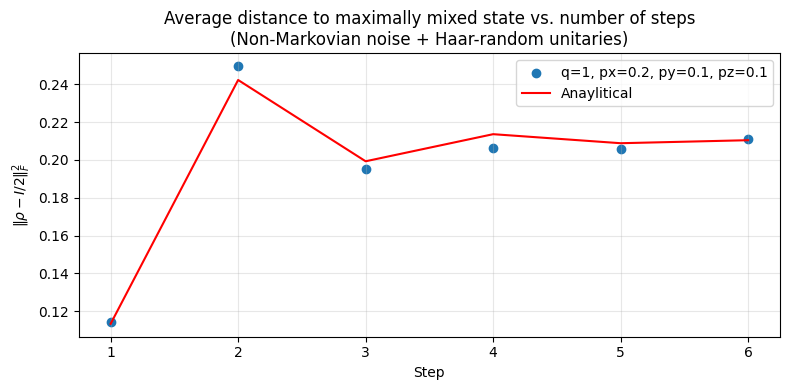

In [25]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(steps, exp_value_list, label=f'q={q}, px={px}, py={py}, pz={pz}')
ax.plot(steps, result, label = "Anaylitical", color = 'red')
ax.set_xlabel('Step')
ax.set_ylabel(r'$\|\rho - I/2\|_F^2$')
ax.set_title('Average distance to maximally mixed state vs. number of steps\n(Non-Markovian noise + Haar-random unitaries)')

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Case Studies on Varying Q and px,py,pz

### Different Q with same px,py,pz

In [59]:
q_list = [0,0.2,0.5,0.8,1]

n_steps = 8
n_samples = 100

p_list = [[0.1,0.1,0.1], [0.2,0.2,0],[0.3,0.2,0.1]]


steps = np.arange(1, n_steps + 1)

#Initial State
rho0 = np.array([[1, 0], [0, 0]], dtype=complex)

#Run Code
result_list = []
for i in range(len(p_list)):
    matrix_samep = []
    px = p_list[i][0]
    py = p_list[i][1]
    pz = p_list[i][2]

    for j in range(len(q_list)):
        exp_value_list = run_trajectory(n_steps, q_list[j], px, py, pz, rho0, n_samples)
        matrix_samep.append(exp_value_list)
    result_list.append(matrix_samep)

KeyboardInterrupt: 

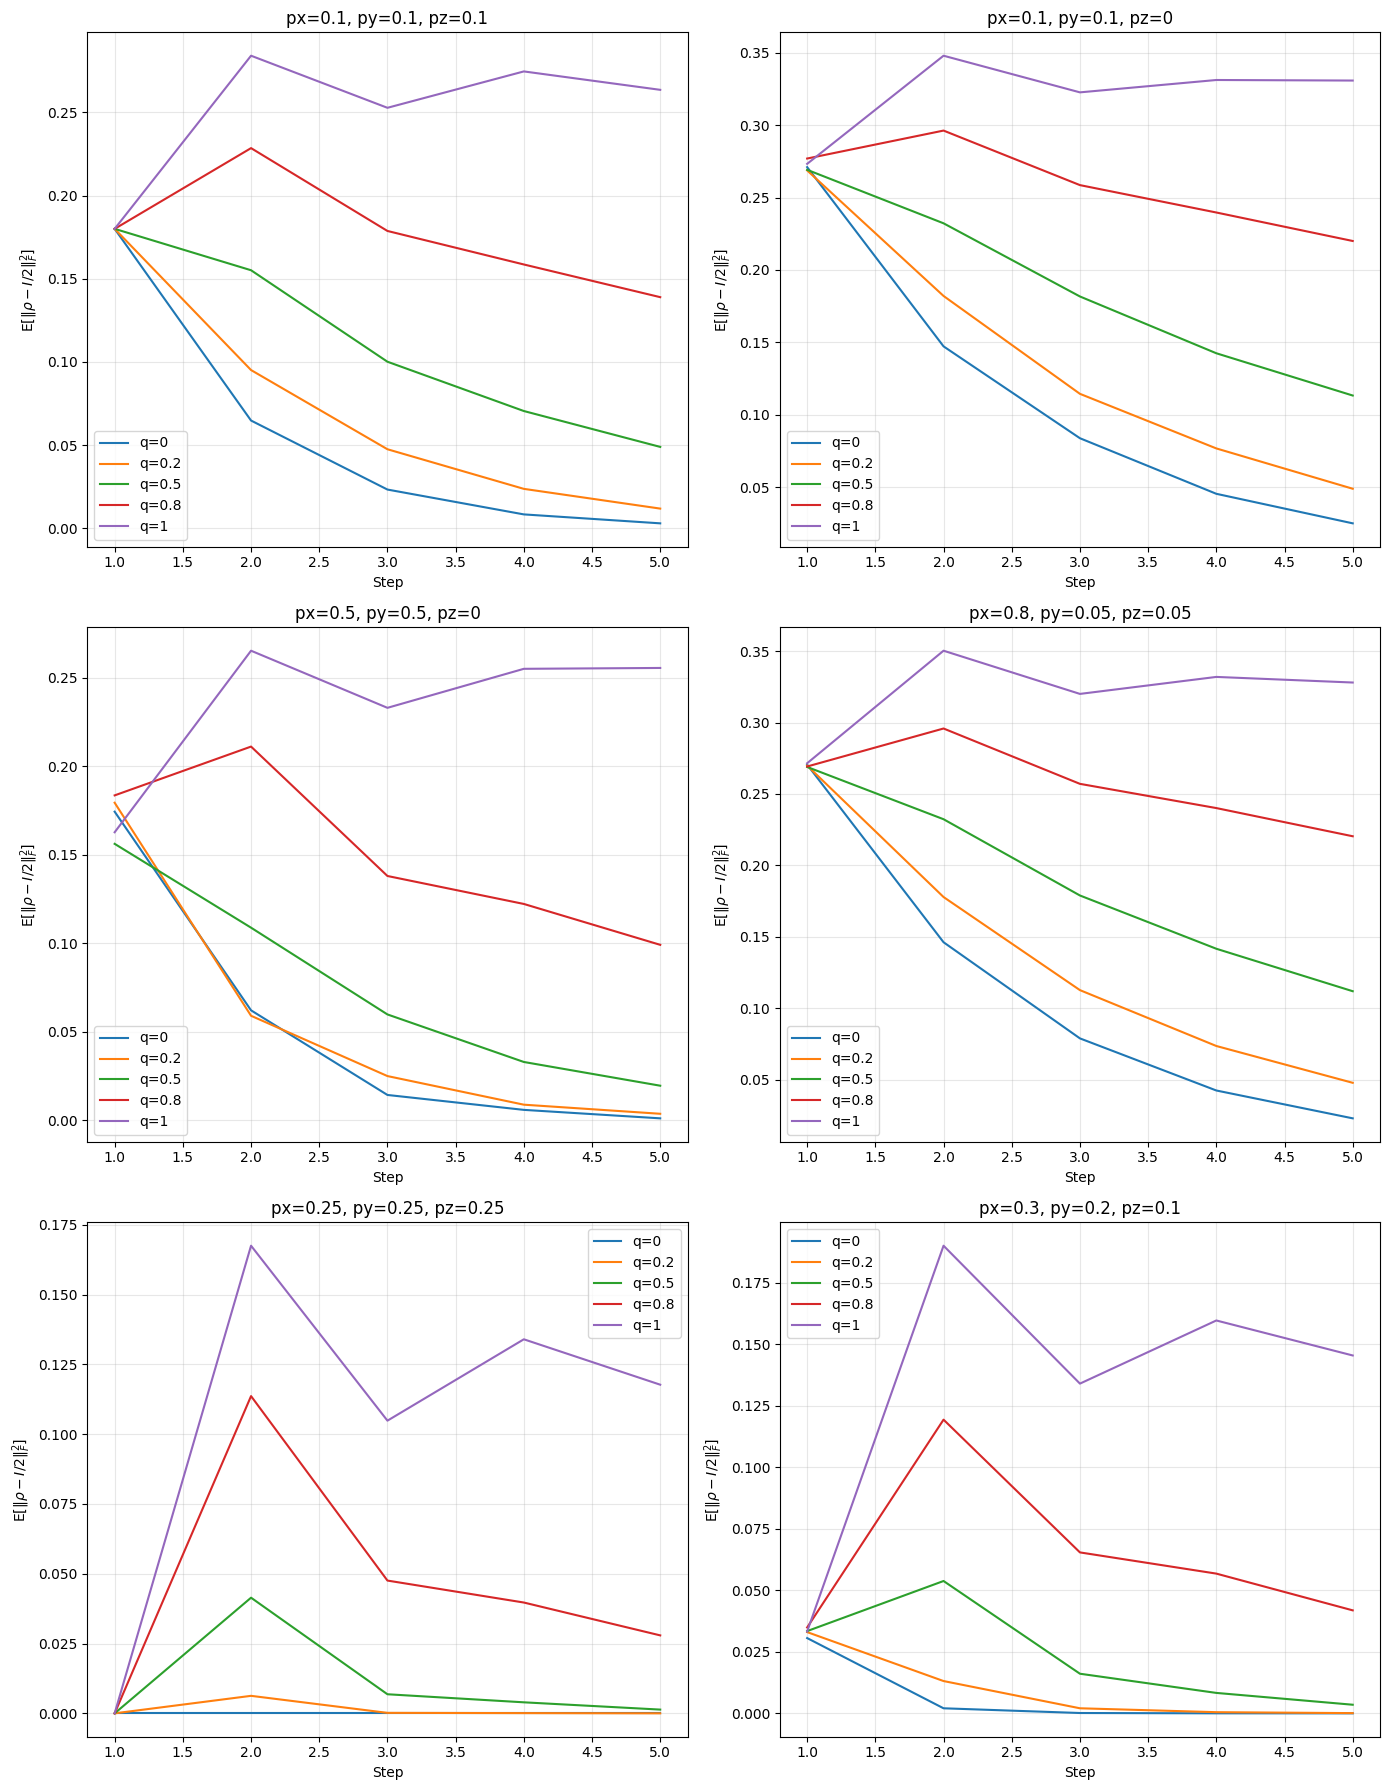

In [56]:
# --- Plot for same probabilites and different qs ---
fig, ax = plt.subplots(3, 2, figsize=(14, 18))

for j in range(len(p_list)):
    row = j // 2
    col = j % 2
    px = p_list[j][0]
    py = p_list[j][1]
    pz = p_list[j][2]
    for i in range(len(q_list)):
        ax[row, col].plot(steps, result_list[j][i], label=f'q={q_list[i]}')
    ax[row, col].set_xlabel('Step')
    ax[row, col].set_ylabel(r'E[$\|\rho - I/2\|_F^2]$')
    ax[row, col].set_title(f'px={px}, py={py}, pz={pz}')
    ax[row, col].legend()
    ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

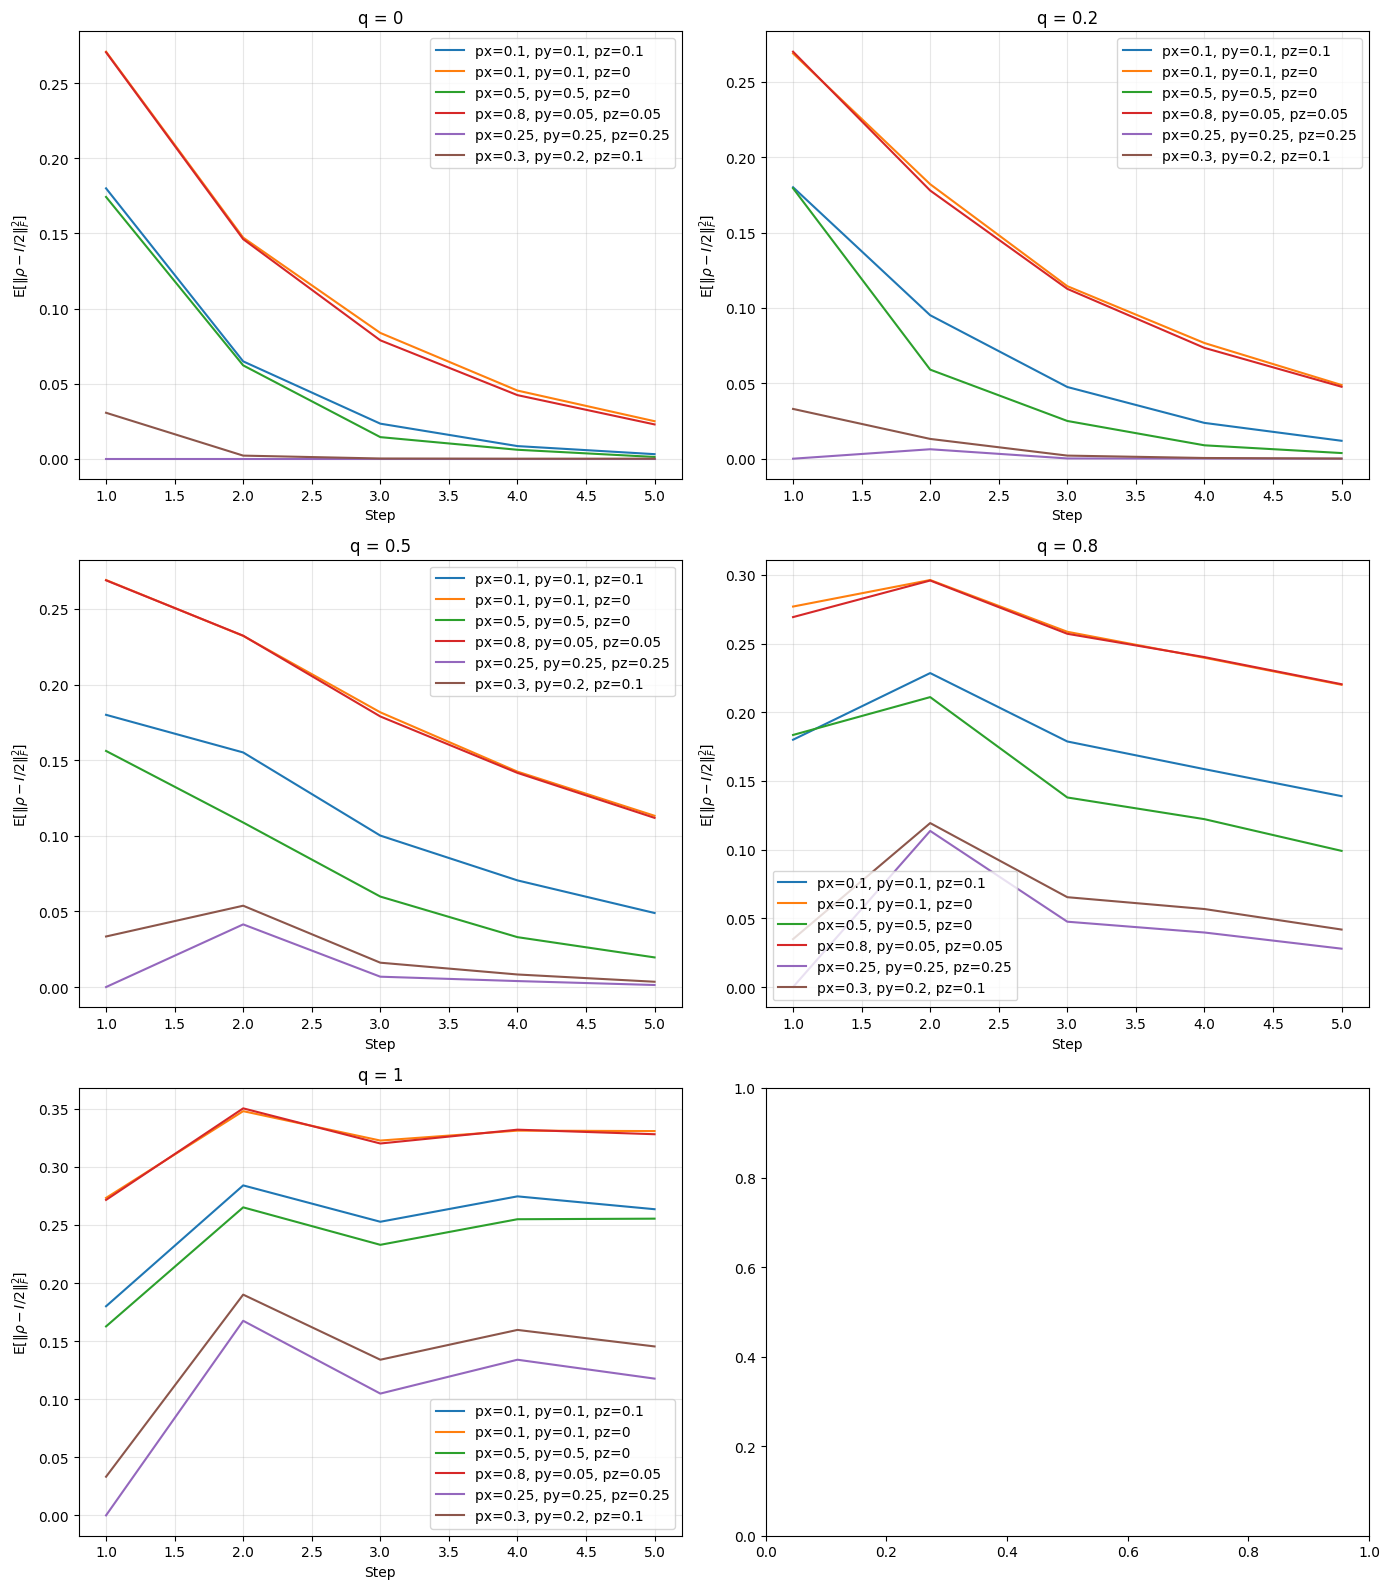

In [57]:
# --- Plot for same qs and different probabilities---
fig, ax = plt.subplots(3,2, figsize=(14, 16))
for j in range(len(q_list)):
    row = j //2
    col = j % 2
    for i in range(len(p_list)):
        px = p_list[i][0]
        py = p_list[i][1]
        pz = p_list[i][2]
        ax[row,col].plot(steps, result_list[i][j], label = f'px={px}, py={py}, pz={pz}')

    ax[row,col].set_xlabel('Step')
    ax[row,col].set_ylabel(r'E[$\|\rho - I/2\|_F^2]$')
    ax[row,col].set_title(f'q = {q_list[j]}')
    ax[row,col].legend()
    ax[row,col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### For Different Initial state